# Modelos de regresion lineal
## Modelo con datos simulados

* y = a + b * x

* X : 100 valores distribuidos segun una N(1.5, 2.5)

* ye = 5 + 1.9 * x + e

* e estara distribuido segun una N(0,0.8)

In [1]:
import pandas as pd
import numpy as np

In [2]:
x = 1.5 + 2.5 * np.random.randn(100)

In [3]:
e = 0 + 0.8 * np.random.randn(100)

In [4]:
y_pred = 5 + 1.9 * x

In [5]:
y_act = 5 + 1.9 * x + e

In [6]:
x_list = x.tolist()
y_pred_list = y_pred.tolist()
y_act_list = y_act.tolist()

In [7]:
data = pd.DataFrame(
    {
        "x": x_list,
        "y_actual": y_act_list,
        "y_prediccion":y_pred_list
    }
)

In [8]:
data.head()

,x,y_actual,y_prediccion
0,-2.759234,-1.584141,-0.242544
1,1.006051,7.545968,6.911497
2,3.522898,11.552777,11.693505
3,2.016895,8.644577,8.832100
4,3.475408,11.085087,11.603275


In [9]:
import matplotlib.pyplot as plt

In [10]:
y_mean = [np.mean(y_act) for i in range(0,len(x_list))]

Text(0.5, 1.0, 'Valor actual vs prediccion')

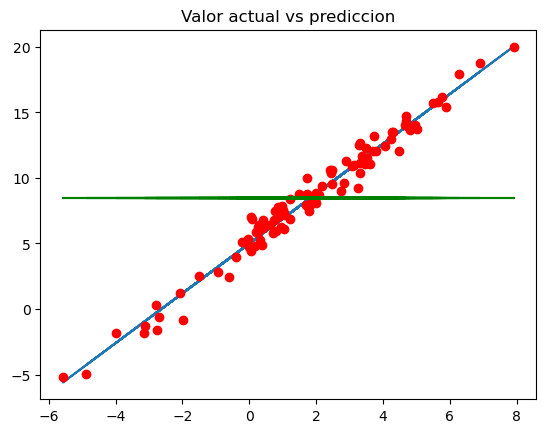

In [11]:
plt.plot(x,y_pred)
plt.plot(x,y_act,"ro")
plt.plot(x,y_mean,"g")
plt.title("Valor actual vs prediccion")

In [12]:
data["SSR"] = (data["y_prediccion"] - np.mean(y_act))**2
data["SSD"] = (data["y_prediccion"] - data["y_actual"])**2
data["SST"] = (data["y_actual"] - np.mean(y_act))**2

In [13]:
SSR = sum(data["SSR"])
SST = sum(data["SST"])
SSD = sum(data["SSD"])

In [14]:
data.head()

,x,y_actual,y_prediccion,SSR,SSD,SST
0,-2.759234,-1.584141,-0.242544,75.316476,1.799882,100.402472
1,1.006051,7.545968,6.911497,2.323996,0.402554,0.792089
2,3.522898,11.552777,11.693505,10.611586,0.019804,9.714535
3,2.016895,8.644577,8.832100,0.156925,0.035165,0.043520
4,3.475408,11.085087,11.603275,10.031870,0.268519,7.017862


In [15]:
SSR + SSD

2367.3768521696657

In [16]:
SST

2403.7169846173942

In [17]:
SSR/SST

0.96028277543703

### Encontrando los valores optimos

In [18]:
x_mean = np.mean(data["x"])
y_mean = np.mean(data["y_actual"])

In [19]:
x_mean, y_mean

(np.float64(1.7759223027884021), np.float64(8.435962365436112))

In [20]:
data["beta_n"] = (data["x"] - x_mean) * (data["y_actual"] - y_mean)
data["beta_d"] = (data["x"] - x_mean)**2

In [21]:
beta = sum(data["beta_n"])/sum(data["beta_d"])

In [22]:
alpha = y_mean - beta * x_mean

In [23]:
alpha,beta

(np.float64(5.0345873958458505), 1.915272399163923)

El modelo lineal obtenido por regresion sera igual a: y = 5.037090649424213 + 1.905343697616636 * x

In [24]:
data["y_model"] = alpha + beta * data["x"]
data.head()

,x,y_actual,y_prediccion,SSR,SSD,SST,beta_n,beta_d,y_model
0,-2.759234,-1.584141,-0.242544,75.316476,1.799882,100.402472,45.442733,20.567641,-0.250097
1,1.006051,7.545968,6.911497,2.323996,0.402554,0.792089,0.685181,0.592702,6.961449
2,3.522898,11.552777,11.693505,10.611586,0.019804,9.714535,5.444998,3.051922,11.781896
3,2.016895,8.644577,8.832100,0.156925,0.035165,0.043520,0.050270,0.058068,8.897491
4,3.475408,11.085087,11.603275,10.031870,0.268519,7.017862,4.502149,2.888252,11.690940


In [25]:
SSR = sum((data["y_model"] - y_mean)**2)
SSD = sum((data["y_model"] - data["y_actual"])**2)
SST = sum((data["y_actual"] - np.mean(y_act))**2)
SSR,SSD,SST

(2345.118075995575, 58.59890862181921, 2403.7169846173942)

In [26]:
R2 = SSR/SST
R2

0.9756215440516403

Text(0.5, 1.0, 'Valor actual vs prediccion')

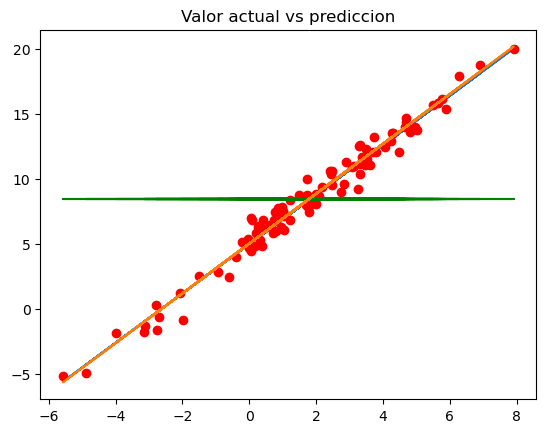

In [27]:
y_mean = [np.mean(y_act) for i in range(0,len(x_list))]
plt.plot(data["x"],data["y_prediccion"])
plt.plot(data["x"],data["y_actual"],"ro")
plt.plot(data["x"],y_mean,"g")
plt.plot(data["x"],data["y_model"])
plt.title("Valor actual vs prediccion")

# Error estandar de los residuos (RSE)

In [30]:
RSE = np.sqrt(SSD/(len(data)-2))
RSE

np.float64(0.7732710049920536)

In [33]:
np.mean(data["y_actual"])

np.float64(8.435962365436112)

In [34]:
RSE/np.mean(data["y_actual"])

np.float64(0.09166363853877602)